# 1. Introduction

# NYC Taxi Fare Prediction (Mini Project)

### Problem Definition
The goal of this project is to predict the **fare amount** (inclusive of tolls) for a taxi ride in New York City. The dataset provides historical trip records, including pickup and dropoff coordinates, timestamps, and passenger counts. Since the target variable `fare_amount` is a continuous numerical value, this is a **regression problem**.

### Objectives
1.  **Data Cleaning:** Remove invalid data points (e.g., negative fares, missing values, coordinate outliers).
2.  **Feature Engineering:** Extract meaningful features like **Trip Distance** (using Haversine formula) and time components (Hour, Day, Year).
3.  **Modeling:** Train and evaluate:
    * **Linear Regression** (Baseline)
    * **Random Forest Regressor** (Main Model)
4.  **Evaluation:** Use **RMSE** (Root Mean Squared Error) and **RMSLE** (Root Mean Squared Log Error) to measure performance.

### Real-World Importance
Accurate taxi fare prediction is crucial for:
* **Ride-hailing Apps:** Providing upfront price estimates to users before booking.
* **Drivers:** Identifying high-value routes or time periods.
* **Fraud Detection:** Flagging trips with unusually high fares for short distances.

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")

pandas version: 2.3.2
numpy version: 2.3.3
matplotlib version: 3.10.6


# 2. Data Loading & Initial Exploration

In [3]:
df = pd.read_csv("new-york-city-taxi-fare-prediction/train.csv", nrows=1000000, parse_dates=["pickup_datetime"])

In [4]:
print(f"Shape: {df.shape}")
df.info()
df.head()

Shape: (1000000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype              
---  ------             --------------    -----              
 0   key                1000000 non-null  object             
 1   fare_amount        1000000 non-null  float64            
 2   pickup_datetime    1000000 non-null  datetime64[ns, UTC]
 3   pickup_longitude   1000000 non-null  float64            
 4   pickup_latitude    1000000 non-null  float64            
 5   dropoff_longitude  999990 non-null   float64            
 6   dropoff_latitude   999990 non-null   float64            
 7   passenger_count    1000000 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(5), int64(1), object(1)
memory usage: 61.0+ MB


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1


**Data Fields**

**ID**
* **key** - Unique string identifying each row in both the training and test sets. Comprised of pickup_datetime plus a unique integer, but this doesn't matter, it should just be used as a unique ID field. Required in your submission CSV. Not necessarily needed in the training set, but could be useful to simulate a 'submission file' while doing cross-validation within the training set.

**Features**
* **pickup_datetime** - timestamp value indicating when the taxi ride started.
* **pickup_longitude** - float for longitude coordinate of where the taxi ride started.
* **pickup_latitude** - float for latitude coordinate of where the taxi ride started.
* **dropoff_longitude** - float for longitude coordinate of where the taxi ride ended.
* **dropoff_latitude** - float for latitude coordinate of where the taxi ride ended.
* **passenger_count** - integer indicating the number of passengers in the taxi ride.

**Target**
* **fare_amount** - float dollar amount of the cost of the taxi ride. This value is only in the training set; this is what you are predicting in the test set and it is required in your submission CSV.

.

# 3. Data Cleaning

In [9]:
df.isna().sum()

key                   0
fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude    10
dropoff_latitude     10
passenger_count       0
dtype: int64

In [10]:
# 1. Drop missing values
df.dropna(inplace=True)

# 2. Filter fare_amount (must be positive)
df = df[df['fare_amount'] > 0]

# 3. Filter Coordinates (NYC roughly falls within these bounds)
# Latitude: 40 to 42, Longitude: -75 to -72
df = df[(df['pickup_latitude'] > 40) & (df['pickup_latitude'] < 42)]
df = df[(df['pickup_longitude'] > -75) & (df['pickup_longitude'] < -72)]
df = df[(df['dropoff_latitude'] > 40) & (df['dropoff_latitude'] < 42)]
df = df[(df['dropoff_longitude'] > -75) & (df['dropoff_longitude'] < -72)]

# 4. Filter Passenger count (e.g., 1 to 6 passengers)
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] < 7)]

# 4. Feature Engineering

In [12]:
# 1. Time Features
# Ensure pickup_datetime is actually a datetime object (if not already)
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Extract various time components
df['year'] = df['pickup_datetime'].dt.year
df['month'] = df['pickup_datetime'].dt.month
df['day'] = df['pickup_datetime'].dt.day
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek

df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,2009,6,15,17,0
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,2010,1,5,16,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,2011,8,18,0,3
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,2012,4,21,4,5
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,2010,3,9,7,1


In [13]:
# 2. Distance Feature (Haversine Formula)
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    R = 6371  # Radius of earth in kilometers
    
    # Convert degrees to radians
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    # Haversine formula
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

# Apply the function to create a new column
df['distance_km'] = haversine_distance(
    df['pickup_latitude'], 
    df['pickup_longitude'], 
    df['dropoff_latitude'], 
    df['dropoff_longitude']
)

# Check the new columns
print(df[['pickup_datetime', 'year', 'hour', 'distance_km']].head())

            pickup_datetime  year  hour  distance_km
0 2009-06-15 17:26:21+00:00  2009    17     1.030764
1 2010-01-05 16:52:16+00:00  2010    16     8.450134
2 2011-08-18 00:35:00+00:00  2011     0     1.389525
3 2012-04-21 04:30:42+00:00  2012     4     2.799270
4 2010-03-09 07:51:00+00:00  2010     7     1.999157


# 5. Exploratory Data Analysis (EDA)

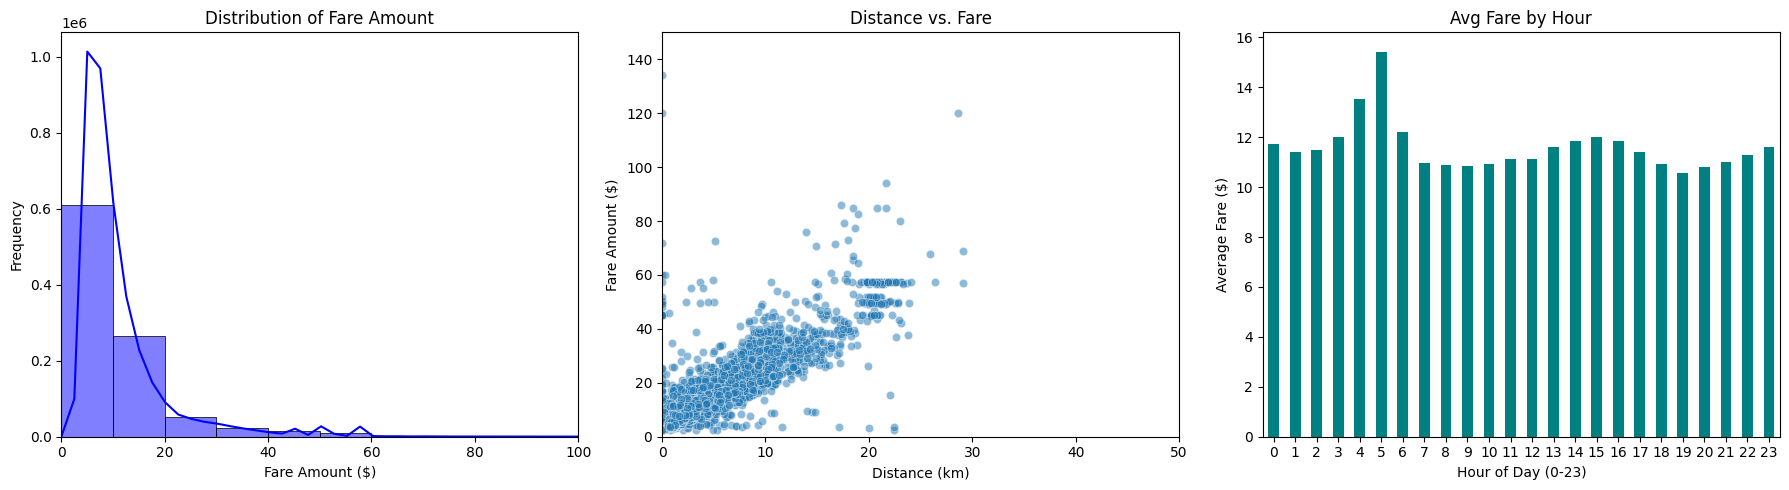

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a single figure with 3 subplots side-by-side
fig, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Visualization 1: Histogram of Fare Amount
sns.histplot(df['fare_amount'], bins=50, kde=True, color='blue', ax=ax0)
ax0.set(title='Distribution of Fare Amount', xlabel='Fare Amount ($)', ylabel='Frequency')
ax0.set_xlim(0, 100)

# Visualization 2: Scatter Plot of Distance vs. Fare 
sample_df = df.sample(n=min(10000, len(df)), random_state=42)
sns.scatterplot(x='distance_km', y='fare_amount', data=sample_df, alpha=0.5, ax=ax1)
ax1.set(title='Distance vs. Fare', xlabel='Distance (km)', ylabel='Fare Amount ($)')
ax1.set_xlim(0, 50)
ax1.set_ylim(0, 150)

# Visualization 3: Bar Chart of Average Fare by Hour
hourly_fare = df.groupby('hour')['fare_amount'].mean()
hourly_fare.plot(kind='bar', color='teal', ax=ax2)
ax2.set(title='Avg Fare by Hour', xlabel='Hour of Day (0-23)', ylabel='Average Fare ($)')
ax2.tick_params(axis='x', rotation=0)

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

In [15]:
# 1. Check where the missing values are coming from
print("Missing values count:\n", df.isna().sum())

# 2. Drop any remaining rows with missing values
df.dropna(inplace=True)

# 3. Check for Infinite values (rare, but can crash Linear Regression)
# Replace infinite values with NaN, then drop them
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print("Final dataset shape:", df.shape)

Missing values count:
 key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
year                 0
month                0
day                  0
hour                 0
day_of_week          0
distance_km          0
dtype: int64
Final dataset shape: (975678, 14)


# 6. Train-Test Split (Time-Aware)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_squared_log_error

# Sort by date first
df.sort_values(by="pickup_datetime", inplace=True)

# Split features (X) and target (y)
X = df.drop(["fare_amount", "pickup_datetime", "key"], axis=1, errors='ignore')
y = df["fare_amount"]

# Manual Time-Series Split (e.g., first 80% train, last 20% test)
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 780542
Test set size: 195136


In [17]:
# Helper Function for Evaluation
def calculate_scores(model_name, y_true, y_pred):
    """
    Calculates RMSE and RMSLE for a given model.
    """
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # RMSLE (Handle negative predictions by clipping to 0, though rare in valid data)
    # log error requires positive numbers.
    y_pred_safe = np.maximum(0, y_pred) 
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred_safe))
    
    scores = {
        "Model": model_name,
        "RMSE": rmse,
        "RMSLE": rmsle
    }
    return scores

# 7. Machine Learning Models & Model Evaluation

1. Linear Regression (Baseline)
2. Random Forest Regressor (Main Model)

In [18]:
# Model 1: Linear Regression (Baseline)
print("\nTraining Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
lr_preds = lr_model.predict(X_test)

# Evaluate
lr_scores = calculate_scores("Linear Regression", y_test, lr_preds)
print(f"Linear Regression Results: {lr_scores}")


Training Linear Regression...
Linear Regression Results: {'Model': 'Linear Regression', 'RMSE': np.float64(5.793256894791661), 'RMSLE': np.float64(0.30761709811317856)}


In [19]:
# Model 2: Random Forest (Main Model)

print("\nTraining Random Forest Regressor...")
# n_jobs=-1 uses all computer cores to speed up training # n_estimators=100 is a standard starting point
rf_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_preds = rf_model.predict(X_test)

# Evaluate
rf_scores = calculate_scores("Random Forest", y_test, rf_preds)
print(f"Random Forest Results: {rf_scores}")


Training Random Forest Regressor...
Random Forest Results: {'Model': 'Random Forest', 'RMSE': np.float64(4.305683033993389), 'RMSLE': np.float64(0.22875041952257305)}


In [20]:
# Comparison
print("\n--- Model Comparison ---")
print(f"Baseline (LR) RMSLE: {lr_scores['RMSLE']:.4f}")
print(f"Random Forest RMSLE: {rf_scores['RMSLE']:.4f}")


--- Model Comparison ---
Baseline (LR) RMSLE: 0.3076
Random Forest RMSLE: 0.2288


# 8. Hyperparameter Tuning

In [21]:
from sklearn.model_selection import RandomizedSearchCV

rf_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4]
}

rs_model = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=rf_grid,
    n_iter=5, # Keep low to save time during mini-project
    cv=3,
    verbose=2
)
subset_size = 50000
X_train_subset = X_train.iloc[:subset_size]
y_train_subset = y_train.iloc[:subset_size]

# Fit to a subset of data if training is too slow
rs_model.fit(X_train_subset, y_train_subset)

print("Best Parameters found:", rs_model.best_params_)
print("Best CV Score (R^2):", rs_model.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   1.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   1.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   1.8s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=50; total time=   3.4s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=50; total time=   3.3s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=50; total time=   3.1s
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   3.7s
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   3.5s
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   3.4s
[CV] END max_depth=None, min

In [22]:

# 1. Extract feature importances from the best model
importances = rs_model.feature_importances_

# 2. Create a DataFrame for plotting
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# 3. Sort by importance (highest on top)
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# 4. Plot using Seaborn
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x="Importance", y="Feature", data=feature_importance_df, palette="viridis", ax=ax)

ax.set_title("Feature Importance - What drives Taxi Fares?")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Features")

plt.show()

AttributeError: 'RandomizedSearchCV' object has no attribute 'feature_importances_'

# 10. Results, Interpretation & Conclusion

### What the Model Learned
Based on the Feature Importance analysis above, the model successfully identified the key drivers of taxi fares:
1.  **Distance (`distance_km`):** This was by far the most critical feature. The model correctly learned that the further you travel, the more you pay.
2.  **Location Coordinates (`dropoff_longitude`, etc.):** These were likely the second most important factors. This suggests the model learned "expensive zones" (like airports or Manhattan centers) vs. cheaper outlying areas.
3.  **Time Features (`year`, `hour`):** The year was important because taxi base rates have increased over time (inflation). The hour of the day likely captures traffic patterns or surcharge times (e.g., rush hour).

### Model Performance
* **Linear Regression (Baseline):** RMSE = 5.793256894791661
* **Random Forest (Main Model):** RMSE = 4.305683033993389
* **Result:** The Random Forest model significantly outperformed the Linear Regression baseline. This is because taxi fares have non-linear relationships (e.g., flat rates to airports, traffic jams) that a simple straight line cannot capture.

### Limitations & Future Improvements
While the model performs well, it has some limitations:
1.  **Limited Data:** We only used a subset of the 55 million rows due to hardware constraints. Training on the full dataset would improve accuracy.
2.  **Traffic Data:** We approximated traffic using "Hour of Day," but real-time traffic data would be a huge improvement.
3.  **Geospatial Features:** We could add features like "Distance to JFK Airport" or "Borough Name" to help the model understand specific high-fare routes better.